In [2]:
import pandas as pd
d = pd.read_csv('data PM10 mean 2025.csv', sep=";")

# Spherical

Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'spherical' Variogram Model
Partial Sill: 5.625114827317033
Full Sill: 11.041277700422334
Range: 1.9442395991101653
Nugget: 5.416162873105302 



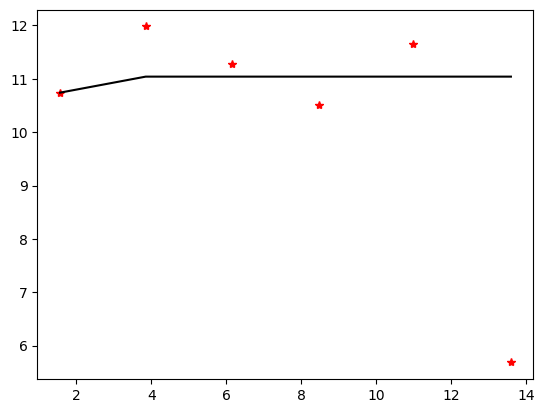

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



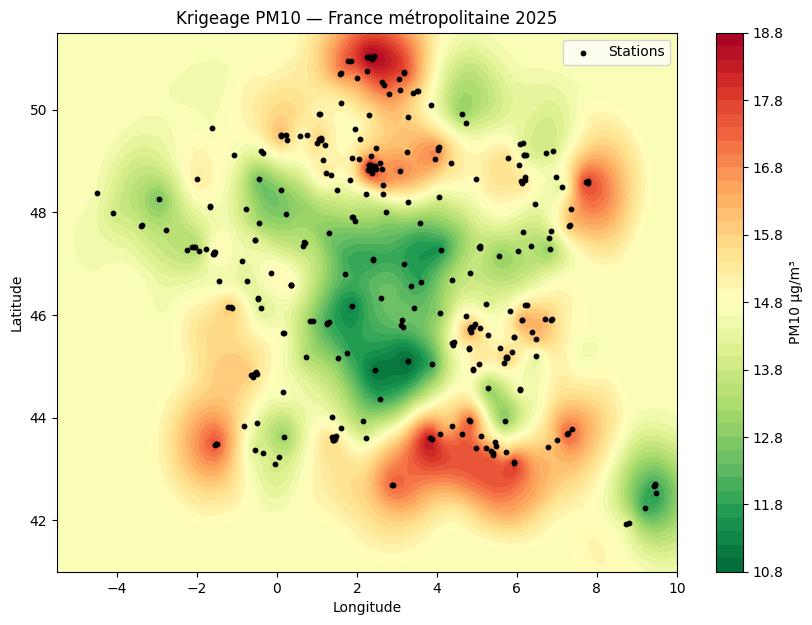

In [4]:
import numpy as np
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt

# Filtrer la France métropolitaine
d_metro = d[
    (d["validité"] == 1) &
    (d["Latitude"].between(41.0, 51.5)) &
    (d["Longitude"].between(-5.5, 10.0))
].dropna(subset=["Latitude", "Longitude", "valeur"])

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

OK = OrdinaryKriging(
    lons, lats, vals,
    variogram_model="spherical",
    verbose=True,
    enable_plotting=True
)

z, variance = OK.execute("grid", grid_lon, grid_lat)

plt.figure(figsize=(10, 7))
plt.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
plt.colorbar(label="PM10 µg/m³")
plt.scatter(lons, lats, c="black", s=10, label="Stations")
plt.title("Krigeage PM10 — France métropolitaine 2025")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

# Gaussian

Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 5.386289812812391
Full Sill: 11.041277002017072
Range: 1.6118207258460842
Nugget: 5.6549871892046815 



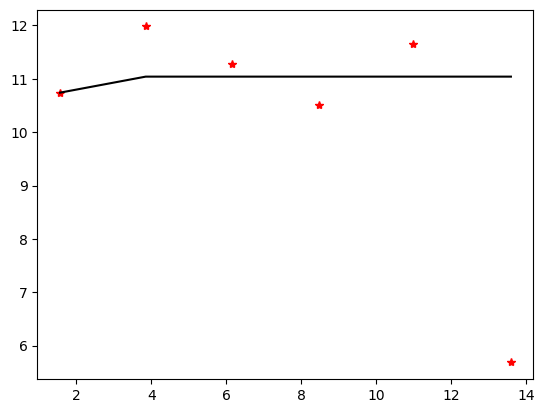

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



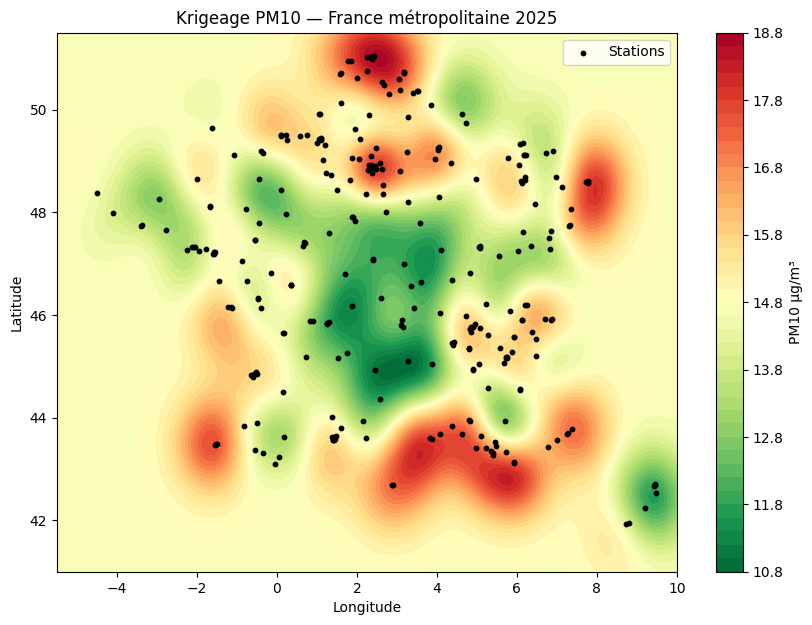

In [5]:
lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

OK = OrdinaryKriging(
    lons, lats, vals,
    variogram_model="gaussian",
    verbose=True,
    enable_plotting=True
)

z, variance = OK.execute("grid", grid_lon, grid_lat)

plt.figure(figsize=(10, 7))
plt.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
plt.colorbar(label="PM10 µg/m³")
plt.scatter(lons, lats, c="black", s=10, label="Stations")
plt.title("Krigeage PM10 — France métropolitaine 2025")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

# Exponential

Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'exponential' Variogram Model
Partial Sill: 11.038381173876804
Full Sill: 11.038381173917445
Range: 1.2890039427377802
Nugget: 4.064182249476165e-11 



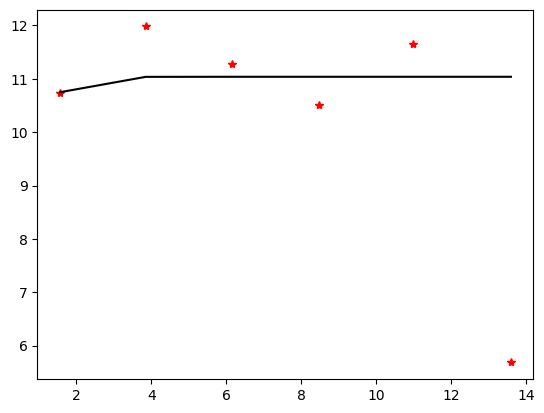

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



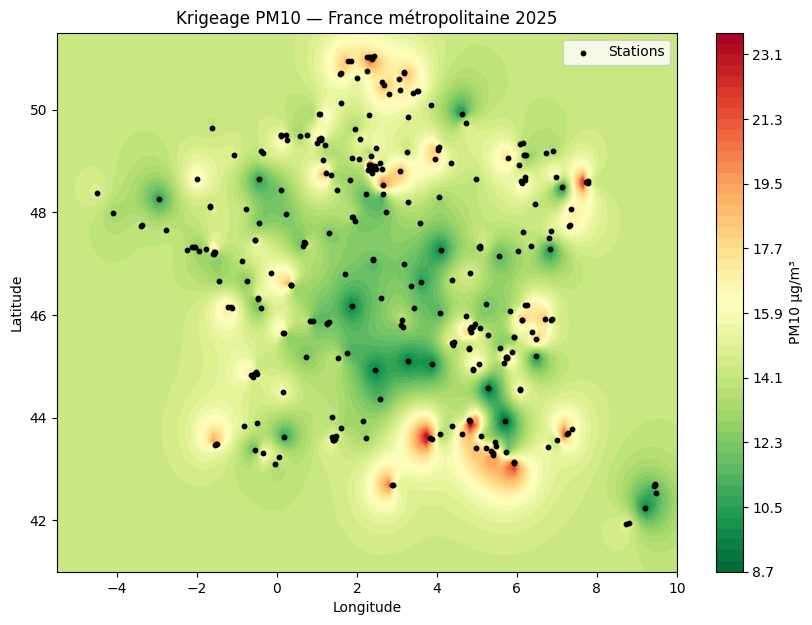

In [6]:
lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

OK = OrdinaryKriging(
    lons, lats, vals,
    variogram_model="exponential",
    verbose=True,
    enable_plotting=True
)

z, variance = OK.execute("grid", grid_lon, grid_lat)

plt.figure(figsize=(10, 7))
plt.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
plt.colorbar(label="PM10 µg/m³")
plt.scatter(lons, lats, c="black", s=10, label="Stations")
plt.title("Krigeage PM10 — France métropolitaine 2025")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

# Comparaison

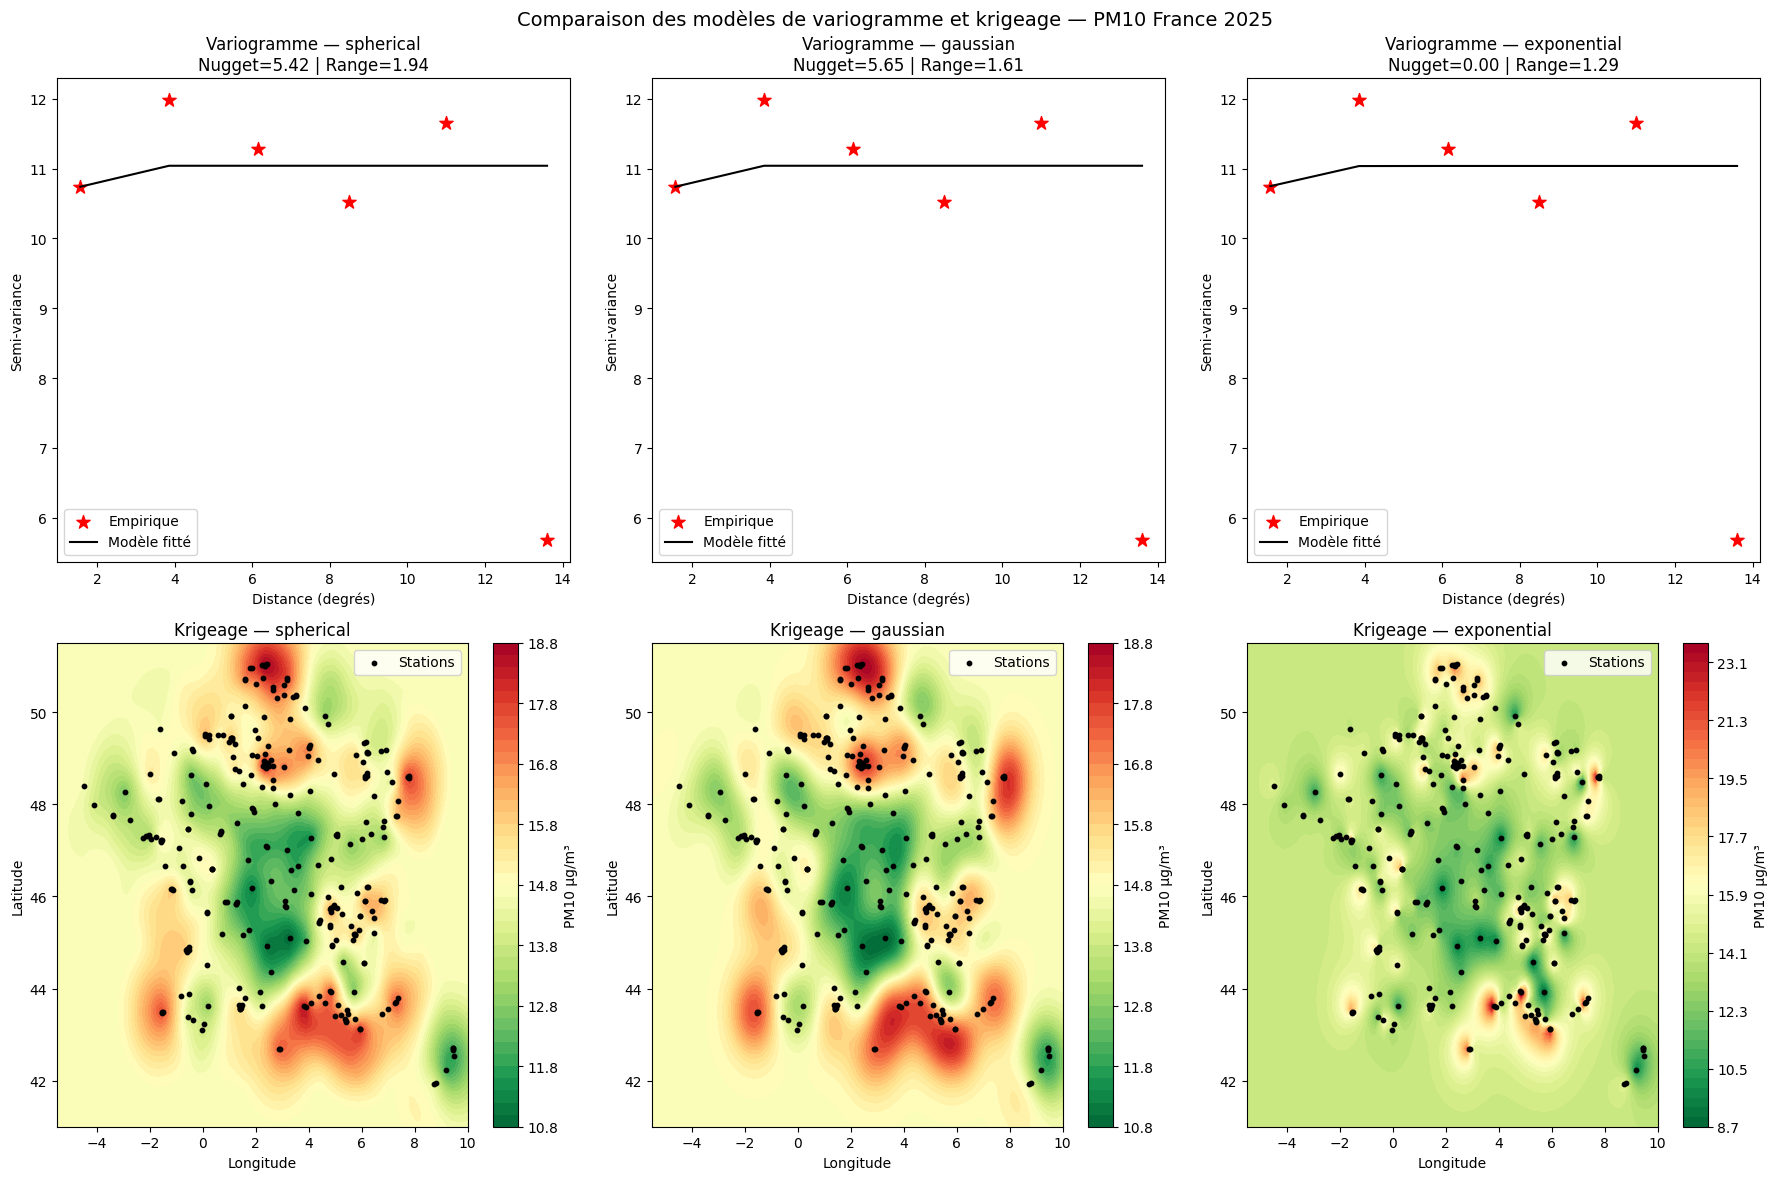

In [8]:
modeles = ["spherical", "gaussian", "exponential"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

for col, modele in enumerate(modeles):
    OK = OrdinaryKriging(
        lons, lats, vals,
        variogram_model=modele,
        verbose=False,
        enable_plotting=False
    )
    
    # --- Ligne 1 : variogramme ---
    ax_vario = axes[0, col]
    lags = OK.lags
    semivariance = OK.semivariance
    variogram_model_points = OK.variogram_function(OK.variogram_model_parameters, lags)
    
    ax_vario.scatter(lags, semivariance, c="red", marker="*", s=100, label="Empirique")
    ax_vario.plot(lags, variogram_model_points, "k-", label="Modèle fitté")
    ax_vario.set_title(f"Variogramme — {modele}\nNugget={OK.variogram_model_parameters[2]:.2f} | Range={OK.variogram_model_parameters[1]:.2f}")
    ax_vario.set_xlabel("Distance (degrés)")
    ax_vario.set_ylabel("Semi-variance")
    ax_vario.legend()

    # --- Ligne 2 : carte krigeage ---
    z, variance = OK.execute("grid", grid_lon, grid_lat)
    
    ax_map = axes[1, col]
    cf = ax_map.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
    ax_map.scatter(lons, lats, c="black", s=10, label="Stations")
    plt.colorbar(cf, ax=ax_map, label="PM10 µg/m³")
    ax_map.set_title(f"Krigeage — {modele}")
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.legend()

plt.suptitle("Comparaison des modèles de variogramme et krigeage — PM10 France 2025", fontsize=14)
plt.tight_layout()
plt.show()